# EMG Autoencoder — Vanilla v5 (Bandpass Filtered + Spectral Regularisation)

Same as vanilla v4, with an added **spectral penalty** on the reconstruction loss.
The penalty discourages the decoder from producing energy above 500 Hz, keeping
reconstructions within the 60–500 Hz bandpass band.

- **All 32 channels**, 512-sample window (256 ms)
- **Bandpass filter**: 60–500 Hz, order 4 Butterworth (`sosfiltfilt`)
- **No BatchNorm, no Dropout** — plain Conv1d encoder/decoder
- **ReLU activations**, MSE + spectral penalty loss, Adam + cosine decay
- **20 epochs**, batch size 256, latent dim 256
- **Spectral penalty**: `LAMBDA_SPEC × mean(|rfft(x̂)|² for bins > 500 Hz)`

Output: `emg_latent_vanilla_v5.hdf5`

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'h5py', 'unidecode'], check=True)

CompletedProcess(args=['/Users/jonathangray/miniconda3/envs/e219/bin/python', '-m', 'pip', 'install', '-q', 'h5py', 'unidecode'], returncode=0)

In [2]:
import sys
sys.path.insert(0, '..')

import h5py
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

from emg2qwerty.charset import charset as get_charset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHARSET = get_charset()
print('device:', device)

device: cpu


## 1. Load and window EMG

In [4]:
from scipy.signal import butter, sosfiltfilt

def bandpass(data, lo=0.0001, hi=500, fs=2000, order=4):
    """Zero-phase Butterworth bandpass. data: (N, C)"""
    sos = butter(order, [lo, hi], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, data, axis=0).astype(np.float32)


SESSION_HDF5 = Path('89335547/2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5')

with h5py.File(SESSION_HDF5, 'r') as f:
    ts         = f['emg2qwerty/timeseries']
    raw_time   = ts['time'][:]
    emg_left   = ts['emg_left'][:].astype(np.float32)
    emg_right  = ts['emg_right'][:].astype(np.float32)
    keystrokes = json.loads(f['emg2qwerty'].attrs['keystrokes'])

emg      = np.concatenate([emg_left, emg_right], axis=1)   # (N, 32)
mean     = emg.mean(0, keepdims=True)
std      = emg.std(0,  keepdims=True) + 1e-8
emg_norm = (emg - mean) / std
emg_norm = bandpass(emg_norm)                               # 60–500 Hz bandpass

WINDOW = 128
STRIDE = 32

starts    = np.arange(0, len(emg_norm) - WINDOW + 1, STRIDE)
win_times = raw_time[starts]
X_windows = np.stack([emg_norm[s:s + WINDOW] for s in starts]).astype(np.float32)

print(f'EMG shape  : {emg.shape}')
print(f'Windows    : {X_windows.shape}')
print(f'Keystrokes : {len(keystrokes)}')

EMG shape  : (1790654, 32)
Windows    : (55954, 128, 32)
Keystrokes : 4432


## 2. Full-session EMG — concatenated signal

All 32 channels (left wrist ch 0–15, right wrist ch 16–31) plotted across the entire
recording.  Each channel is offset vertically for readability.  Keystroke times are
marked as grey vertical lines.

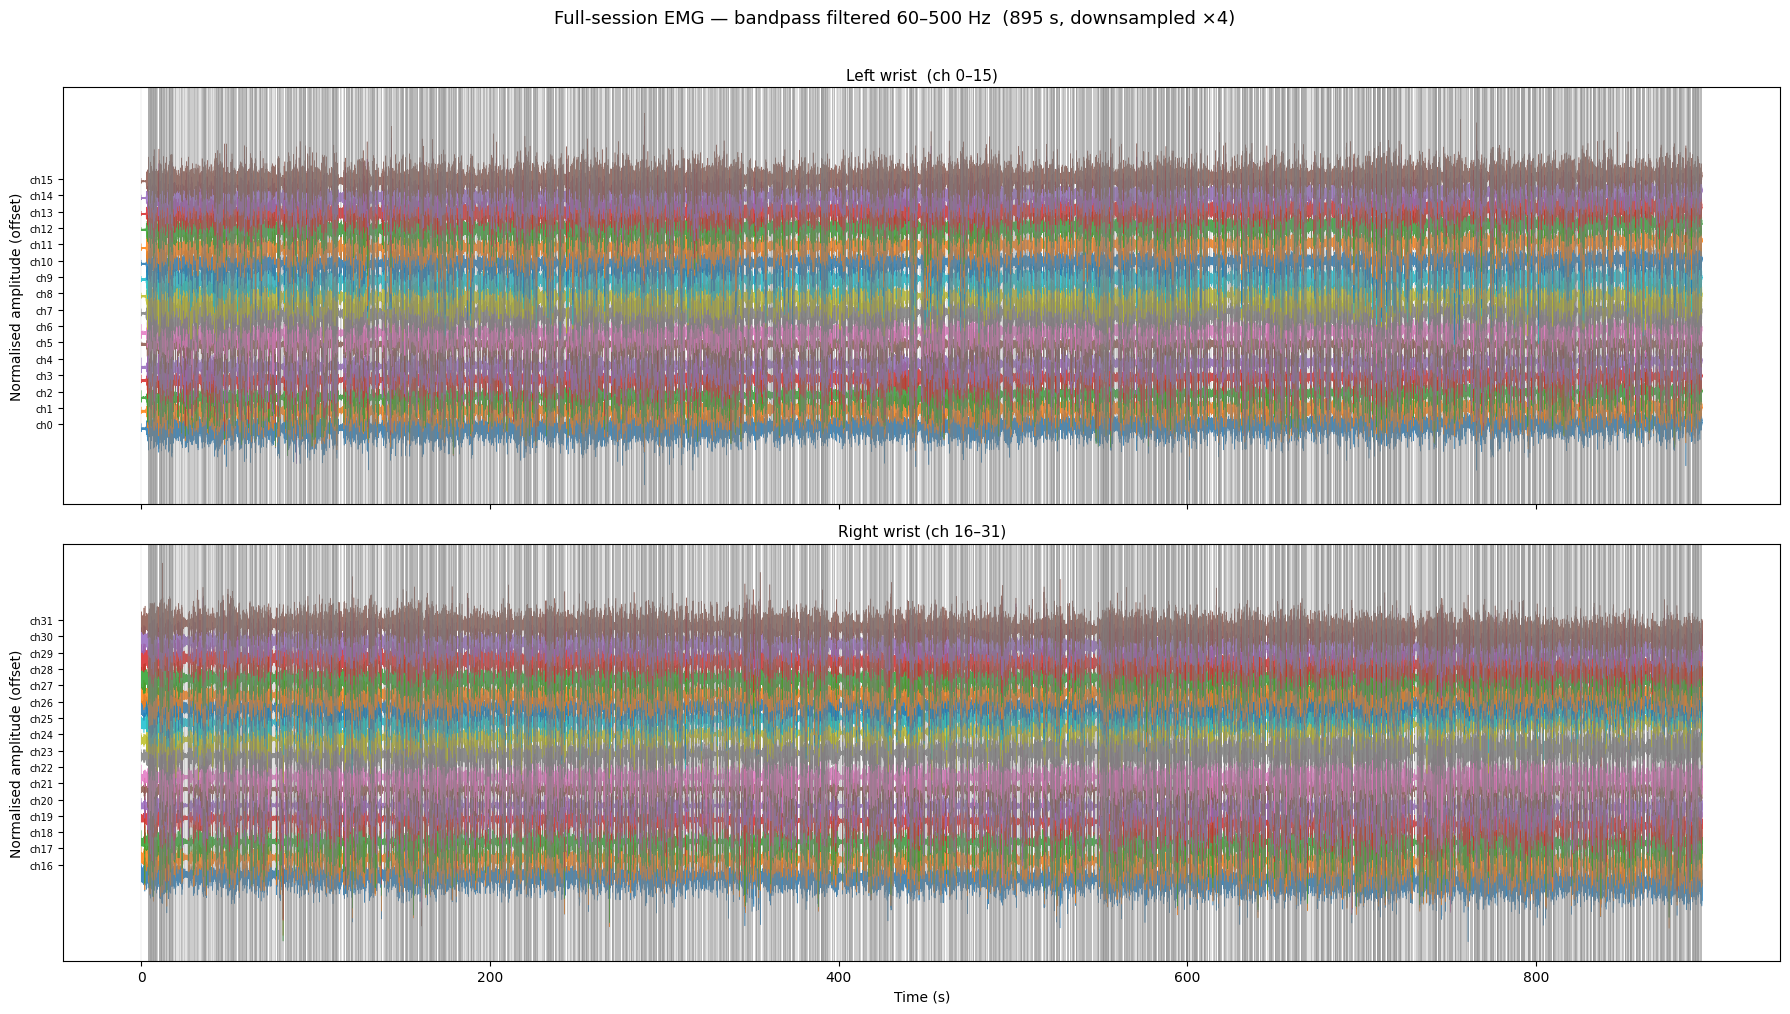

Duration: 895.3 s  |  samples plotted: 447,664  |  keystrokes: 4432


In [5]:
# Downsample for plotting (keep every Kth sample so rendering stays fast)
PLOT_DS = 4                          # downsample factor: 2000 Hz → 500 Hz
t_plot  = raw_time[::PLOT_DS]
sig     = emg_norm[::PLOT_DS]        # (T', 32) — bandpass-filtered, normalised

# Convert absolute timestamps to seconds relative to session start
t_sec = t_plot - t_plot[0]

OFFSET  = 4.0                        # vertical spacing between channels
N_CH    = sig.shape[1]               # 32

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

for ax, ch_slice, title in [
    (axes[0], slice(0,  16), 'Left wrist  (ch 0–15)'),
    (axes[1], slice(16, 32), 'Right wrist (ch 16–31)'),
]:
    channels = sig[:, ch_slice]
    n = channels.shape[1]
    offsets = np.arange(n) * OFFSET
    ax.plot(t_sec, channels + offsets, lw=0.4, alpha=0.85)

    # Keystroke markers
    for ks in keystrokes:
        ks_t = ks['start'] - t_plot[0]
        if 0 <= ks_t <= t_sec[-1]:
            ax.axvline(ks_t, color='gray', lw=0.4, alpha=0.4)

    ax.set_yticks(offsets)
    ax.set_yticklabels([f'ch{i}' for i in range(ch_slice.start, ch_slice.stop)],
                       fontsize=7)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Normalised amplitude (offset)')
    ax.grid(axis='x', lw=0.3, alpha=0.5)

axes[1].set_xlabel('Time (s)')
fig.suptitle(
    f'Full-session EMG — bandpass filtered 60–500 Hz  '
    f'({t_sec[-1]:.0f} s, downsampled ×{PLOT_DS})',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()
print(f'Duration: {t_sec[-1]:.1f} s  |  samples plotted: {len(t_sec):,}  |  keystrokes: {len(keystrokes)}')

### 2b. Heatmap view — all 32 channels

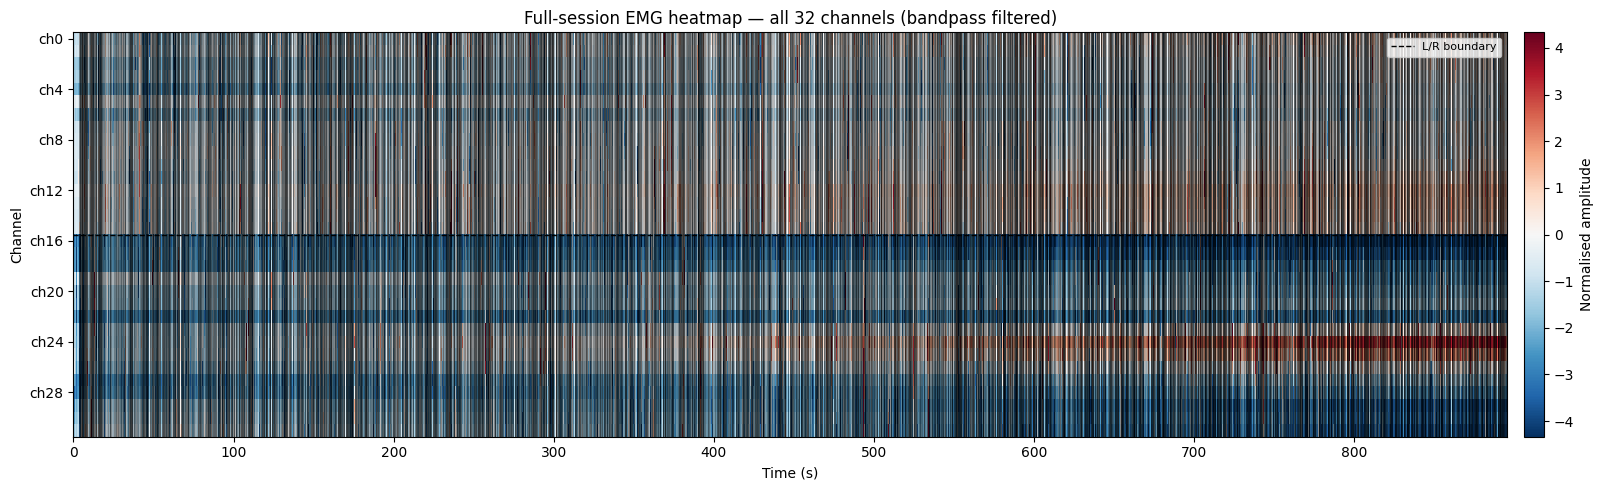

In [6]:
# Further downsample for the heatmap (imshow renders best with ~1–5 k columns)
HM_DS   = max(1, len(t_sec) // 4000)
t_hm    = t_sec[::HM_DS]
sig_hm  = sig[::HM_DS].T           # (32, T'')

vmax = np.percentile(np.abs(sig_hm), 98)

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(
    sig_hm, aspect='auto', interpolation='nearest',
    cmap='RdBu_r', vmin=-vmax, vmax=vmax,
    extent=[t_hm[0], t_hm[-1], 31.5, -0.5]
)
plt.colorbar(im, ax=ax, label='Normalised amplitude', pad=0.01)

for ks in keystrokes:
    ks_t = ks['start'] - t_plot[0]
    if 0 <= ks_t <= t_hm[-1]:
        ax.axvline(ks_t, color='k', lw=0.5, alpha=0.35)

ax.set_yticks(range(0, 32, 4))
ax.set_yticklabels([f'ch{i}' for i in range(0, 32, 4)])
ax.axhline(15.5, color='k', lw=1.0, ls='--', label='L/R boundary')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Channel')
ax.set_title('Full-session EMG heatmap — all 32 channels (bandpass filtered)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Per-window keystroke labels

In [7]:
WIN_DUR    = WINDOW / 2000.0
win_labels = []
for t0 in win_times:
    t1   = t0 + WIN_DUR
    labs = [CHARSET.key_to_label(k['key'])
            for k in keystrokes
            if t0 <= k['start'] < t1 and k['key'] in CHARSET]
    win_labels.append(labs)

n_with = sum(1 for l in win_labels if l)
print(f'Windows with ≥1 keystroke: {n_with} / {len(win_labels)} ({100*n_with/len(win_labels):.1f}%)')

Windows with ≥1 keystroke: 17622 / 55954 (31.5%)


## 4. Model — vanilla Conv1d autoencoder

No BatchNorm, no Dropout. Plain Conv1d → ReLU stack.

In [27]:
class VanillaConv1dAE(nn.Module):
    """Conv1d autoencoder — no BatchNorm, no Dropout. Input/output: (N, WINDOW, n_channels)."""

    def __init__(self, n_channels=32, latent_dim=256, window=512):
        super().__init__()
        self.encoder_cnn = nn.Sequential(
            nn.Conv1d(n_channels, 32,  5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(32,         64,  5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(64,         128, 5, stride=2, padding=2), nn.ReLU(),
        )
        with torch.no_grad():
            self._enc_len = self.encoder_cnn(
                torch.zeros(1, n_channels, window)).shape[-1]

        self.fc_enc = nn.Linear(128 * self._enc_len, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 128 * self._enc_len)

        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose1d(128, 64,         4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(64,  32,         4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(32,  n_channels, 4, stride=2, padding=1),
        )

    def encode(self, x):
        h = self.encoder_cnn(x.transpose(1, 2))
        return self.fc_enc(h.flatten(1))

    def decode(self, z):
        h = self.fc_dec(z).view(z.size(0), 128, self._enc_len)
        return self.decoder_cnn(h).transpose(1, 2)

    def forward(self, x):
        return self.decode(self.encode(x))


LATENT_DIM = 256
ae = VanillaConv1dAE(latent_dim=LATENT_DIM, window=WINDOW).to(device)
print(f'Parameters : {sum(p.numel() for p in ae.parameters()):,}')
print(f'Enc length : {ae._enc_len} time steps')
print(f'Latent dim : {LATENT_DIM}')

Parameters : 1,152,608
Enc length : 16 time steps
Latent dim : 256


## 5. Train

Loss = MSE(reconstruction, input) + λ · spectral_penalty(reconstruction)

The spectral penalty sums the rfft energy in bins above 500 Hz of the *reconstructed*
signal.  The input is already bandpass-filtered so those bins should be near zero;
the penalty prevents the decoder from leaking energy back into the high-frequency range.

Train: 44763  Val: 11191
Spectral cutoff bin: 64  (1000 Hz)  lambda=10.0
Epoch   1 | lr=1.00e-03 | train recon=2.86020  spec=0.01629 | val recon=4.16304  spec=0.00003
Epoch   5 | lr=1.00e-03 | train recon=1.88958  spec=0.00524 | val recon=3.20803  spec=0.00110
Epoch  10 | lr=1.00e-03 | train recon=1.38104  spec=0.00000 | val recon=2.55532  spec=0.00000
Epoch  15 | lr=1.00e-03 | train recon=1.17392  spec=0.00198 | val recon=2.21924  spec=0.00398
Epoch  20 | lr=1.00e-03 | train recon=1.13115  spec=0.00021 | val recon=2.07245  spec=0.00001


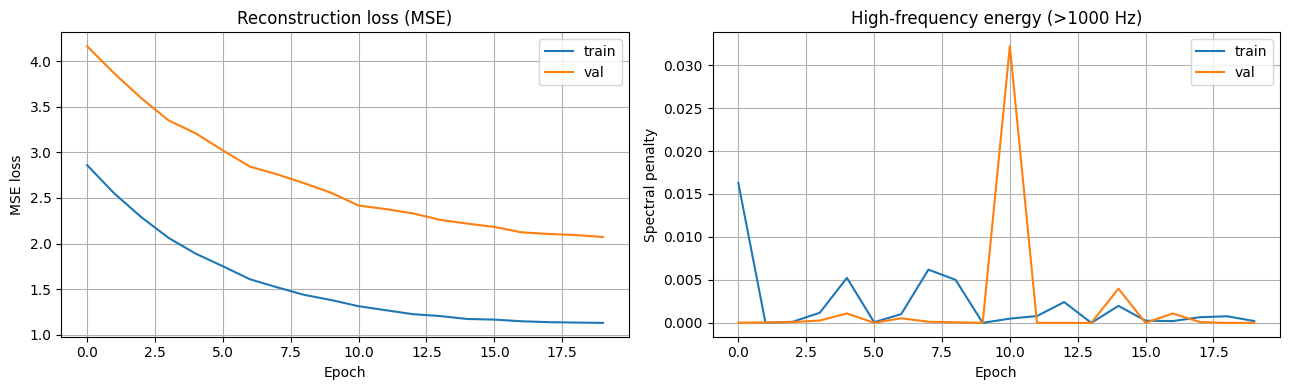

In [28]:
FS          = 2000
HF_CUTOFF   = 1000                            # Hz — penalise energy above this
LAMBDA_SPEC = 1e1                            # spectral penalty weight
_cutoff_bin = int(WINDOW * HF_CUTOFF / FS)   # = 128 for WINDOW=512

def spectral_penalty(x_recon):
    """Mean high-frequency energy (>HF_CUTOFF Hz) in the reconstructed signal.
    x_recon: (B, WINDOW, C) — time-domain reconstruction."""
    X = torch.fft.rfft(x_recon, dim=1)                   # (B, WINDOW//2+1, C)
    return X[:, _cutoff_bin:, :].abs().pow(2).mean()


class EMGDataset(Dataset):
    def __init__(self, windows):
        self.w = torch.tensor(windows, dtype=torch.float32)
    def __len__(self): return len(self.w)
    def __getitem__(self, i): return self.w[i]

n_train  = int(0.8 * len(X_windows))
train_ds = EMGDataset(X_windows[:n_train])
val_ds   = EMGDataset(X_windows[n_train:])
train_ld = DataLoader(train_ds, batch_size=256, shuffle=True,  drop_last=True, num_workers=0)
val_ld   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=0)
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}')
print(f'Spectral cutoff bin: {_cutoff_bin}  ({HF_CUTOFF} Hz)  lambda={LAMBDA_SPEC}')

NUM_EPOCHS = 20
opt   = torch.optim.Adam(ae.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS, eta_min=1e-3)

tr_losses, vl_losses = [], []
tr_spec,   vl_spec   = [], []

for epoch in range(NUM_EPOCHS):
    ae.train()
    tot_recon, tot_spec, n = 0.0, 0.0, 0
    for x in train_ld:
        x      = x.to(device)
        x_hat  = ae(x)
        r_loss = F.mse_loss(x_hat, x)
        s_loss = spectral_penalty(x_hat)
        loss   = r_loss + LAMBDA_SPEC * s_loss
        opt.zero_grad(); loss.backward(); opt.step()
        tot_recon += r_loss.item() * x.size(0)
        tot_spec  += s_loss.item() * x.size(0)
        n         += x.size(0)
    tr_losses.append(tot_recon / n)
    tr_spec.append(tot_spec / n)

    ae.eval()
    tot_recon, tot_spec, n = 0.0, 0.0, 0
    with torch.no_grad():
        for x in val_ld:
            x      = x.to(device)
            x_hat  = ae(x)
            r_loss = F.mse_loss(x_hat, x)
            s_loss = spectral_penalty(x_hat)
            tot_recon += r_loss.item() * x.size(0)
            tot_spec  += s_loss.item() * x.size(0)
            n         += x.size(0)
    vl_losses.append(tot_recon / n)
    vl_spec.append(tot_spec / n)
    sched.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        lr = opt.param_groups[0]['lr']
        print(f'Epoch {epoch+1:3d} | lr={lr:.2e} | '
              f'train recon={tr_losses[-1]:.5f}  spec={tr_spec[-1]:.5f} | '
              f'val recon={vl_losses[-1]:.5f}  spec={vl_spec[-1]:.5f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(tr_losses, label='train'); ax1.plot(vl_losses, label='val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE loss')
ax1.set_title('Reconstruction loss (MSE)'); ax1.legend(); ax1.grid(True)

ax2.plot(tr_spec, label='train'); ax2.plot(vl_spec, label='val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Spectral penalty')
ax2.set_title(f'High-frequency energy (>{HF_CUTOFF} Hz)')
ax2.legend(); ax2.grid(True)

plt.tight_layout(); plt.show()

## 6. Reconstruction quality across the full session

**6a** — Per-window MSE plotted over session time, so you can see where the model
reconstructs well vs poorly (e.g. during keystrokes vs rest).

**6b** — Example original-vs-reconstructed traces sampled from six evenly-spaced
points across the recording, showing both the time-domain waveform and PSD.

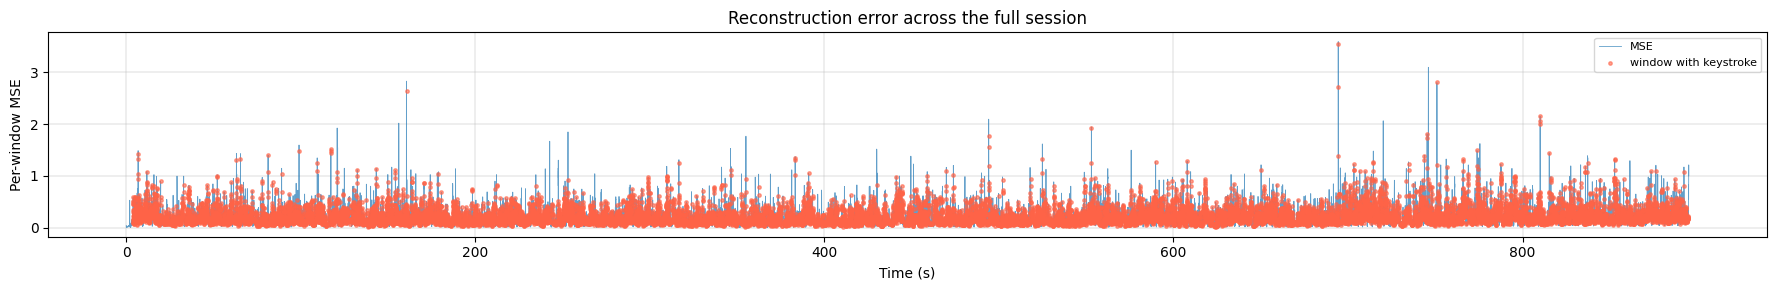

MSE  mean=0.21414  rest=0.20181  keystroke=0.24096


In [25]:
from scipy.signal import welch

ae.eval()

# 6a: per-window MSE across the full session
all_mse = []
full_ld = DataLoader(EMGDataset(X_windows), batch_size=256, shuffle=False)
with torch.no_grad():
    for x in full_ld:
        x = x.to(device)
        recon = ae(x)
        mse = F.mse_loss(recon, x, reduction='none').mean(dim=(1, 2))
        all_mse.append(mse.cpu().numpy())

win_mse = np.concatenate(all_mse)                  # (n_windows,)
t_win   = win_times - win_times[0]                 # seconds from session start

# Mark which windows contain a keystroke
has_key = np.array([bool(l) for l in win_labels])

fig, ax = plt.subplots(figsize=(18, 3))
ax.plot(t_win, win_mse, lw=0.6, alpha=0.7, label='MSE')
ax.scatter(t_win[has_key], win_mse[has_key], s=6, c='tomato', zorder=3,
           label='window with keystroke', alpha=0.6)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Per-window MSE')
ax.set_title('Reconstruction error across the full session')
ax.legend(fontsize=8); ax.grid(True, lw=0.3)
plt.tight_layout(); plt.show()

print(f'MSE  mean={win_mse.mean():.5f}  '
      f'rest={win_mse[~has_key].mean():.5f}  '
      f'keystroke={win_mse[has_key].mean():.5f}')

### 6b. Example reconstructions at six points across the recording

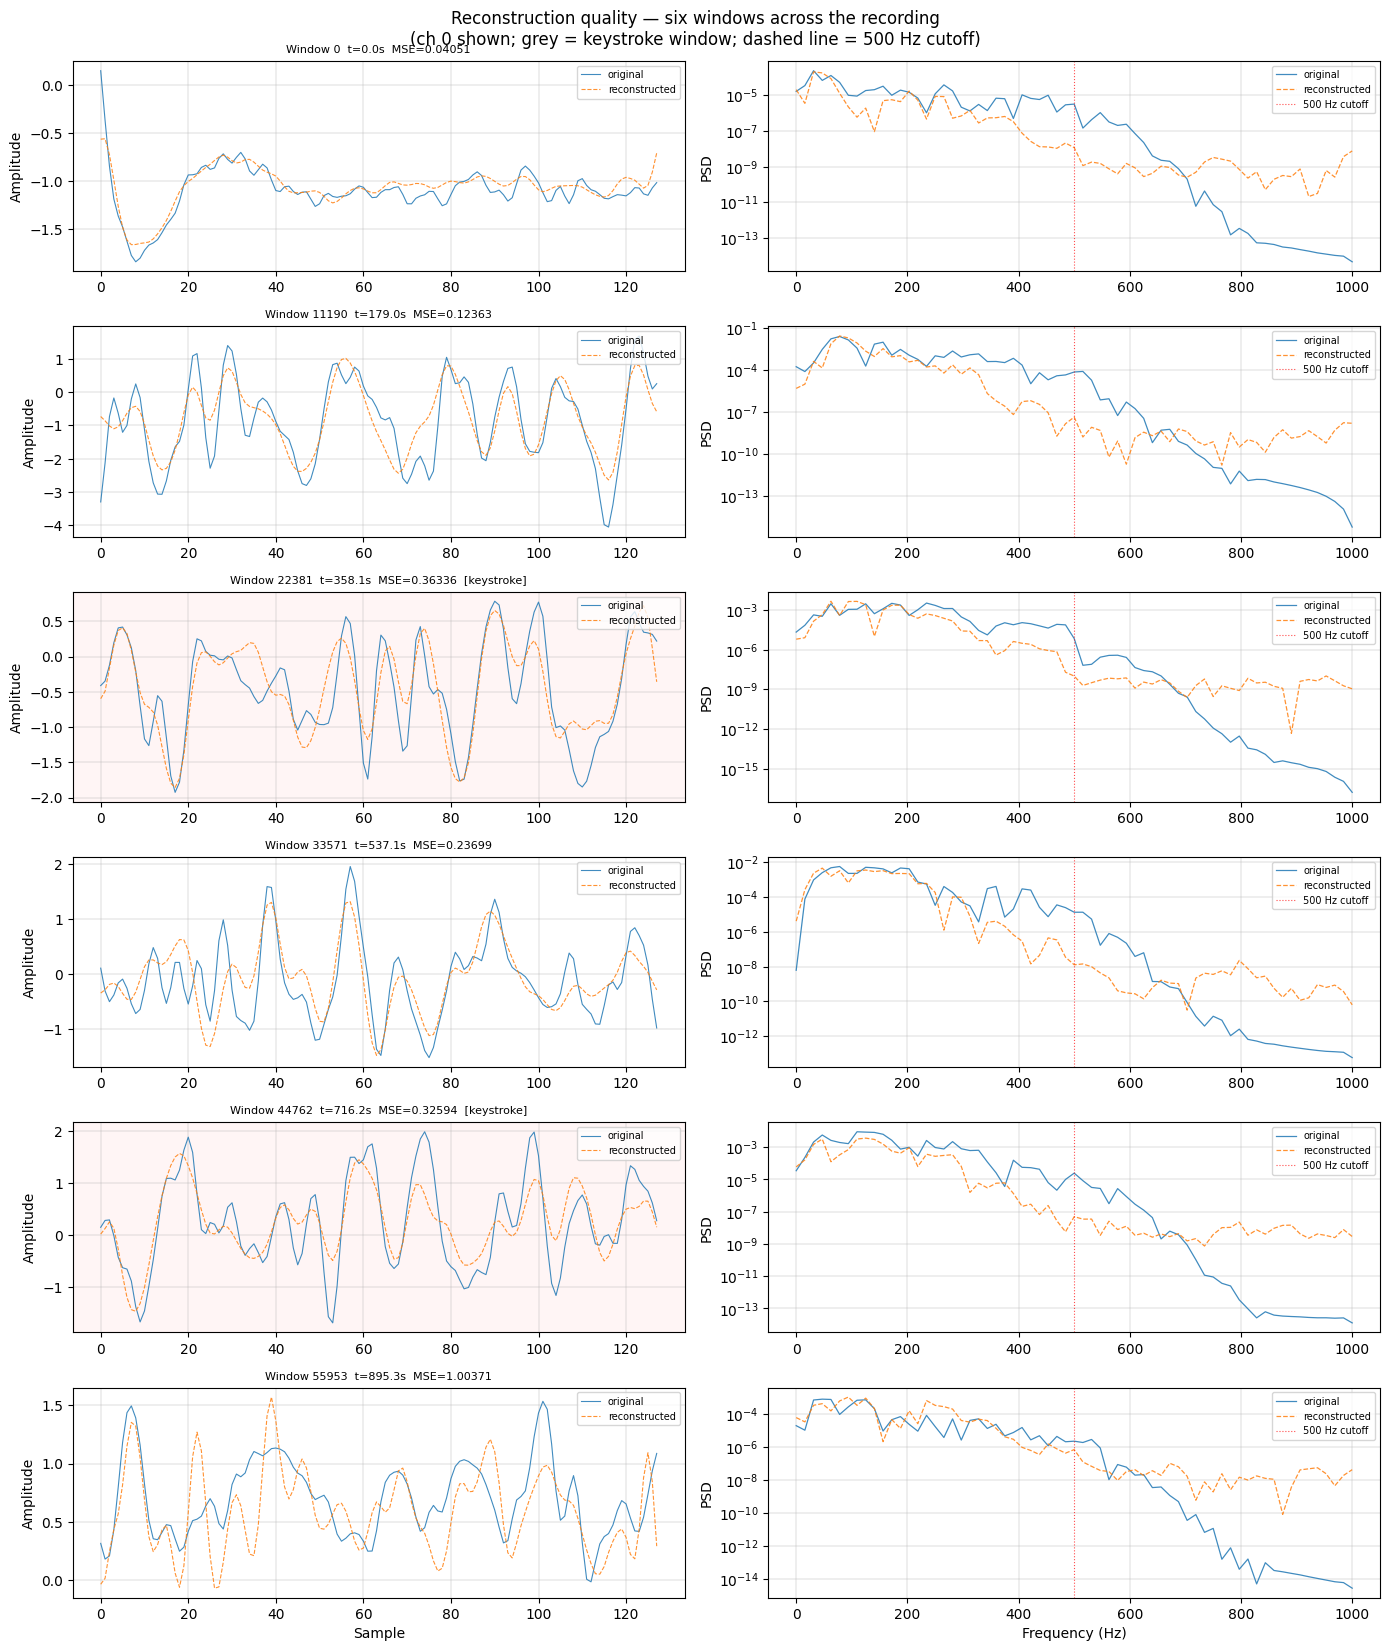

In [26]:
N_EXAMPLES = 6
CH         = 0          # channel to display in time-domain panel

# Pick indices evenly spaced across all windows
example_idx = np.linspace(0, len(X_windows) - 1, N_EXAMPLES, dtype=int)

fig, axes = plt.subplots(N_EXAMPLES, 2, figsize=(14, N_EXAMPLES * 2.8))
fig.suptitle('Reconstruction quality — six windows across the recording\n'
             f'(ch {CH} shown; grey = keystroke window; dashed line = {HF_CUTOFF} Hz cutoff)',
             fontsize=12)

with torch.no_grad():
    batch = torch.tensor(X_windows[example_idx], dtype=torch.float32).to(device)
    recons = ae(batch).cpu().numpy()

for row, (wi, x_true, x_rec) in enumerate(zip(example_idx, X_windows[example_idx], recons)):
    ax_t, ax_f = axes[row]
    t_label = f't={t_win[wi]:.1f}s'
    mse_val = win_mse[wi]
    ks_flag = '  [keystroke]' if has_key[wi] else ''
    title   = f'Window {wi}  {t_label}  MSE={mse_val:.5f}{ks_flag}'

    # Time domain
    ax_t.plot(x_true[:, CH], lw=0.8, label='original', alpha=0.85)
    ax_t.plot(x_rec[:, CH],  lw=0.8, label='reconstructed', alpha=0.85, ls='--')
    if has_key[wi]:
        ax_t.set_facecolor('#fff5f5')
    ax_t.set_title(title, fontsize=8)
    ax_t.set_ylabel('Amplitude')
    ax_t.legend(fontsize=7, loc='upper right')
    ax_t.grid(True, lw=0.3)

    # PSD — mark the spectral penalty cutoff
    f1, p1 = welch(x_true[:, CH], fs=FS, nperseg=256)
    f2, p2 = welch(x_rec[:, CH],  fs=FS, nperseg=256)
    ax_f.semilogy(f1, p1, lw=0.9, alpha=0.85, label='original')
    ax_f.semilogy(f2, p2, lw=0.9, alpha=0.85, ls='--', label='reconstructed')
    ax_f.axvline(HF_CUTOFF, color='red', lw=0.8, ls=':', alpha=0.7, label=f'{HF_CUTOFF} Hz cutoff')
    ax_f.set_ylabel('PSD')
    ax_f.legend(fontsize=7, loc='upper right')
    ax_f.grid(True, lw=0.3)

axes[-1, 0].set_xlabel('Sample')
axes[-1, 1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

## 7. Extract latents and linear probe

In [ ]:
ae.eval()
all_latents = []
full_ld = DataLoader(EMGDataset(X_windows), batch_size=256, shuffle=False)

with torch.no_grad():
    for x in full_ld:
        all_latents.append(ae.encode(x.to(device)).cpu().numpy())

latent = np.concatenate(all_latents, axis=0)
print(f'Latent matrix: {latent.shape}')

# Linear probe
single_key_idx = [i for i, l in enumerate(win_labels) if len(l) == 1]
X_p = latent[[i for i in single_key_idx]]
y_p = np.array([win_labels[i][0] for i in single_key_idx])

from collections import Counter
from sklearn.linear_model import LogisticRegression
counts = Counter(y_p)
keep   = np.array([k for k, v in counts.items() if v >= 5])
mask   = np.isin(y_p, keep)
X_p, y_p = X_p[mask], y_p[mask]

split = int(0.8 * len(X_p))
clf = LogisticRegression(max_iter=500, C=0.1, solver='lbfgs', multi_class='multinomial')
clf.fit(X_p[:split], y_p[:split])
chance = 1 / len(keep)
print(f'\nLinear probe ({len(keep)} classes, {len(X_p)} samples)')
print(f'  Train acc : {clf.score(X_p[:split], y_p[:split]):.3f}')
print(f'  Val acc   : {clf.score(X_p[split:], y_p[split:]):.3f}')
print(f'  Chance    : {chance:.3f}')

## 8. Save latents to HDF5

In [ ]:
OUT_PATH   = Path('emg_latent_vanilla_v5.hdf5')
latent_dim = latent.shape[1]

dtype = np.dtype([('latent', np.float32, (latent_dim,)), ('time', np.float64)])
ts_structured = np.empty(len(latent), dtype=dtype)
ts_structured['latent'] = latent.astype(np.float32)
ts_structured['time']   = win_times.astype(np.float64)

with h5py.File(OUT_PATH, 'w') as out_f:
    grp = out_f.create_group('emg2qwerty')

    with h5py.File(SESSION_HDF5, 'r') as src_f:
        for key, val in src_f['emg2qwerty'].attrs.items():
            grp.attrs[key] = val

    grp.attrs['lambda_spec'] = LAMBDA_SPEC
    grp.attrs['hf_cutoff_hz'] = HF_CUTOFF

    grp.create_dataset('timeseries', data=ts_structured, compression='gzip')
    grp.create_dataset('latent', data=latent.astype(np.float32), compression='gzip')
    grp.create_dataset('time',   data=win_times.astype(np.float64), compression='gzip')

print(f'Saved {OUT_PATH}')
print(f'  latent : {latent.shape}  float32')
print(f'  time   : {win_times.shape}  float64')
print(f'  lambda_spec={LAMBDA_SPEC}  hf_cutoff={HF_CUTOFF} Hz')
print()
print('Drop-in usage in latent_ctc.ipynb:')
print('  LATENT_HDF5 = Path("emg_latent_vanilla_v5.hdf5")')